In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

print(df.shape)
df.head()

(1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# 1. Compreensão do Problema


In [ ]:
# Distribuição de nota
df['quality'].value_counts().sort_index()

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


Realizar a transformação da variável de qualidade em classificação
binária.

In [ ]:
# Transformação em classificação binária
# Alta qualidade = nota >= 7 = 1
# Baixa/Média qualidade = nota < 7 = 0
df['quality_label'] = np.where(df['quality'] >= 7, 1, 0)
df['quality_label'].value_counts()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
# Percentual
df['quality_label'].value_counts(normalize=True) * 100

,proportion
quality_label,
0,86.089239
1,13.910761


# 2. Análise Exploratória de Dados (EDA)

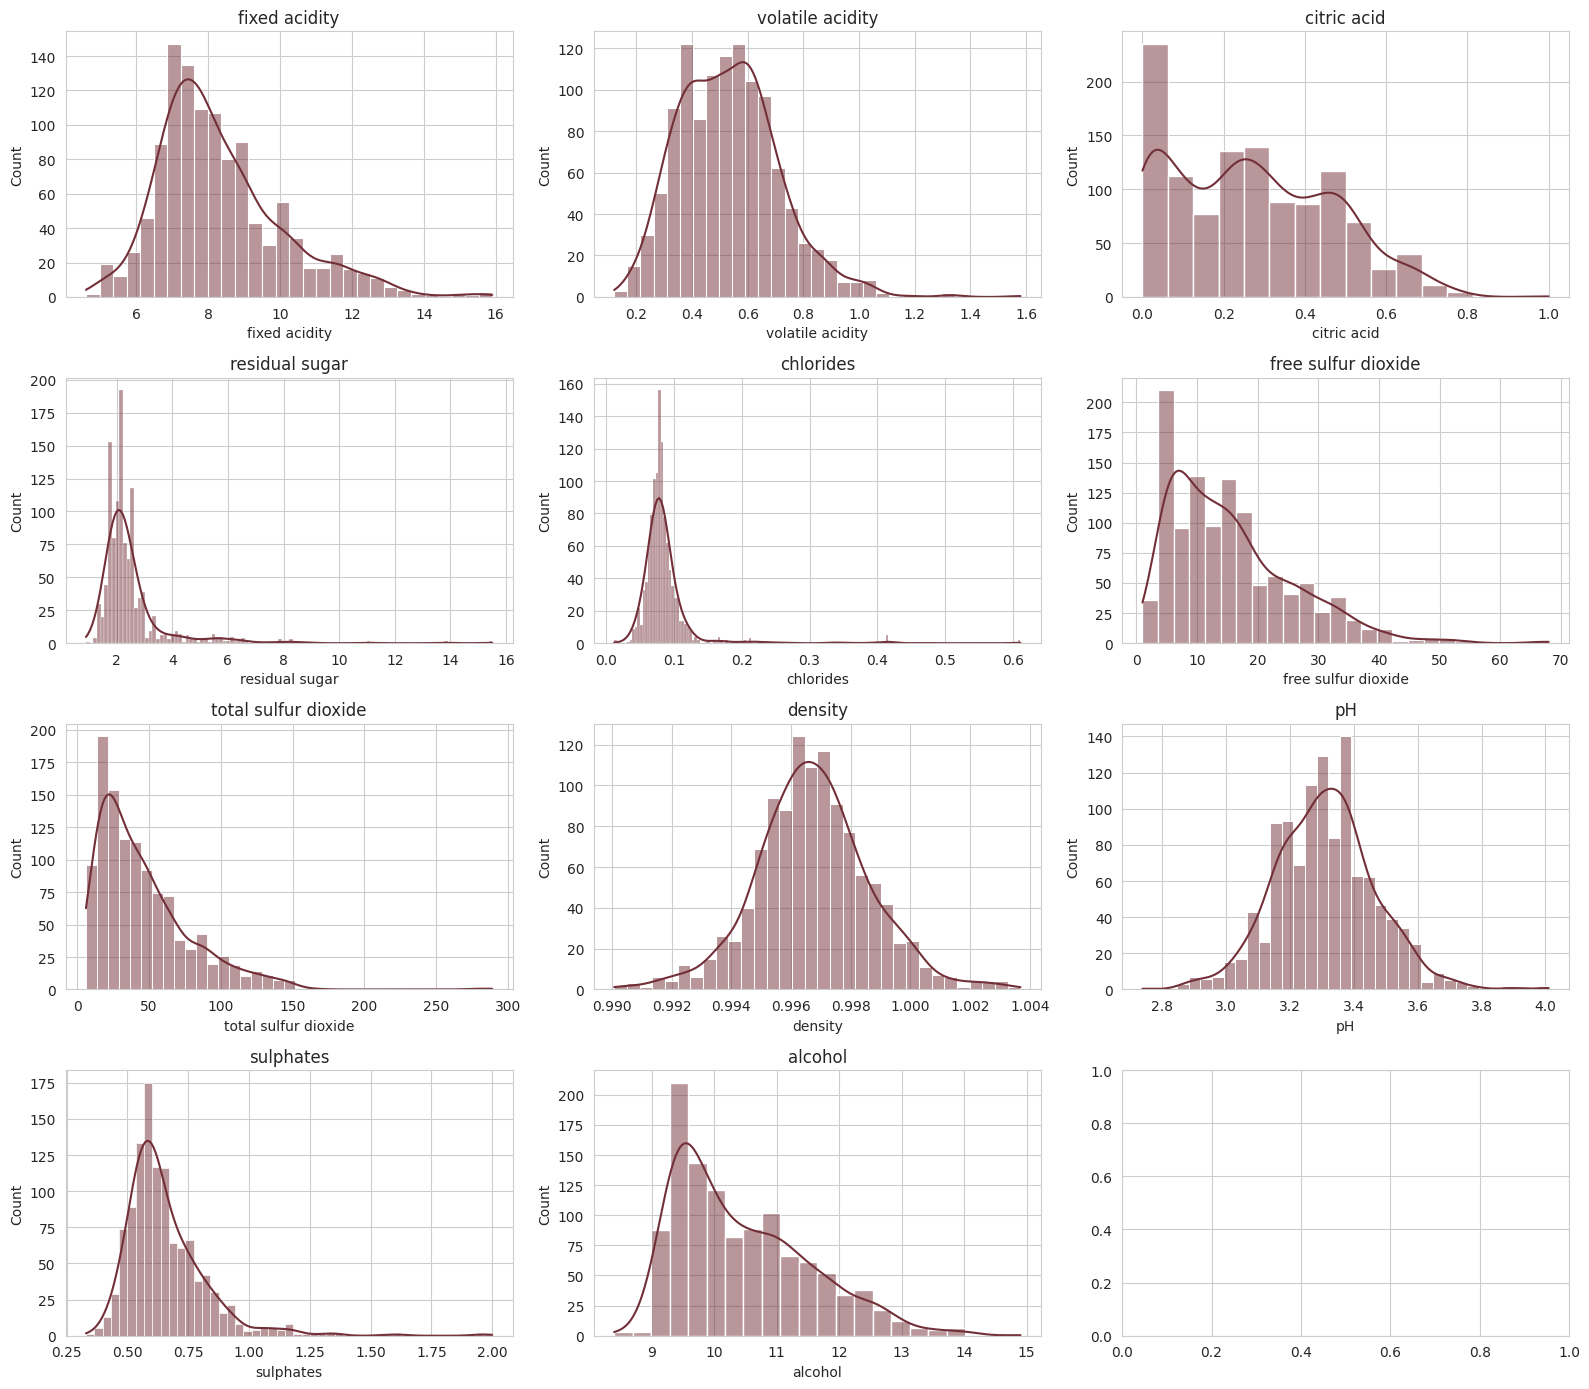

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Histogramas
cols = df.columns.drop(['quality', 'quality_label'])

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#722F37')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

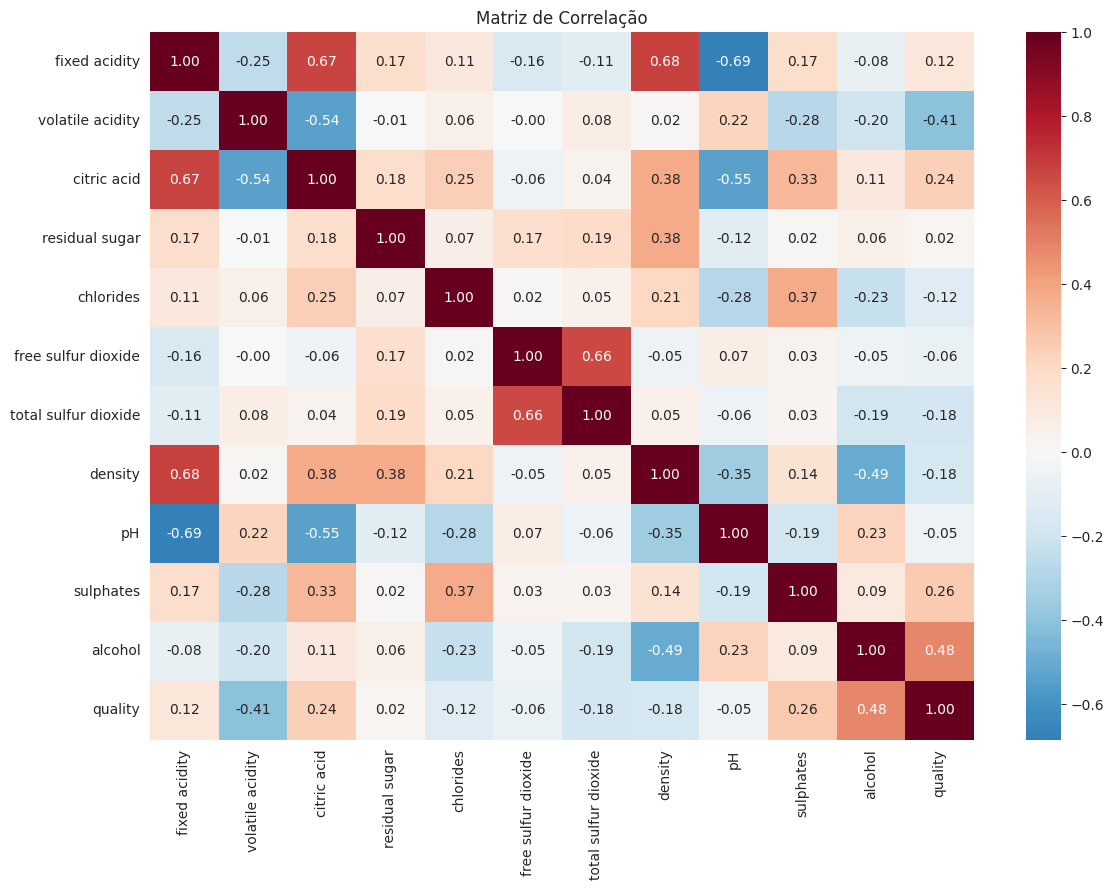

In [ ]:
# Mapa de Calor
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['quality_label']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

In [ ]:
# Correlação com a variável
corr_target = df.drop(columns=['quality']).corr()['quality_label'].sort_values(ascending=False)
print(corr_target)

quality_label           1.000000
alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523
Name: quality_label, dtype: float64


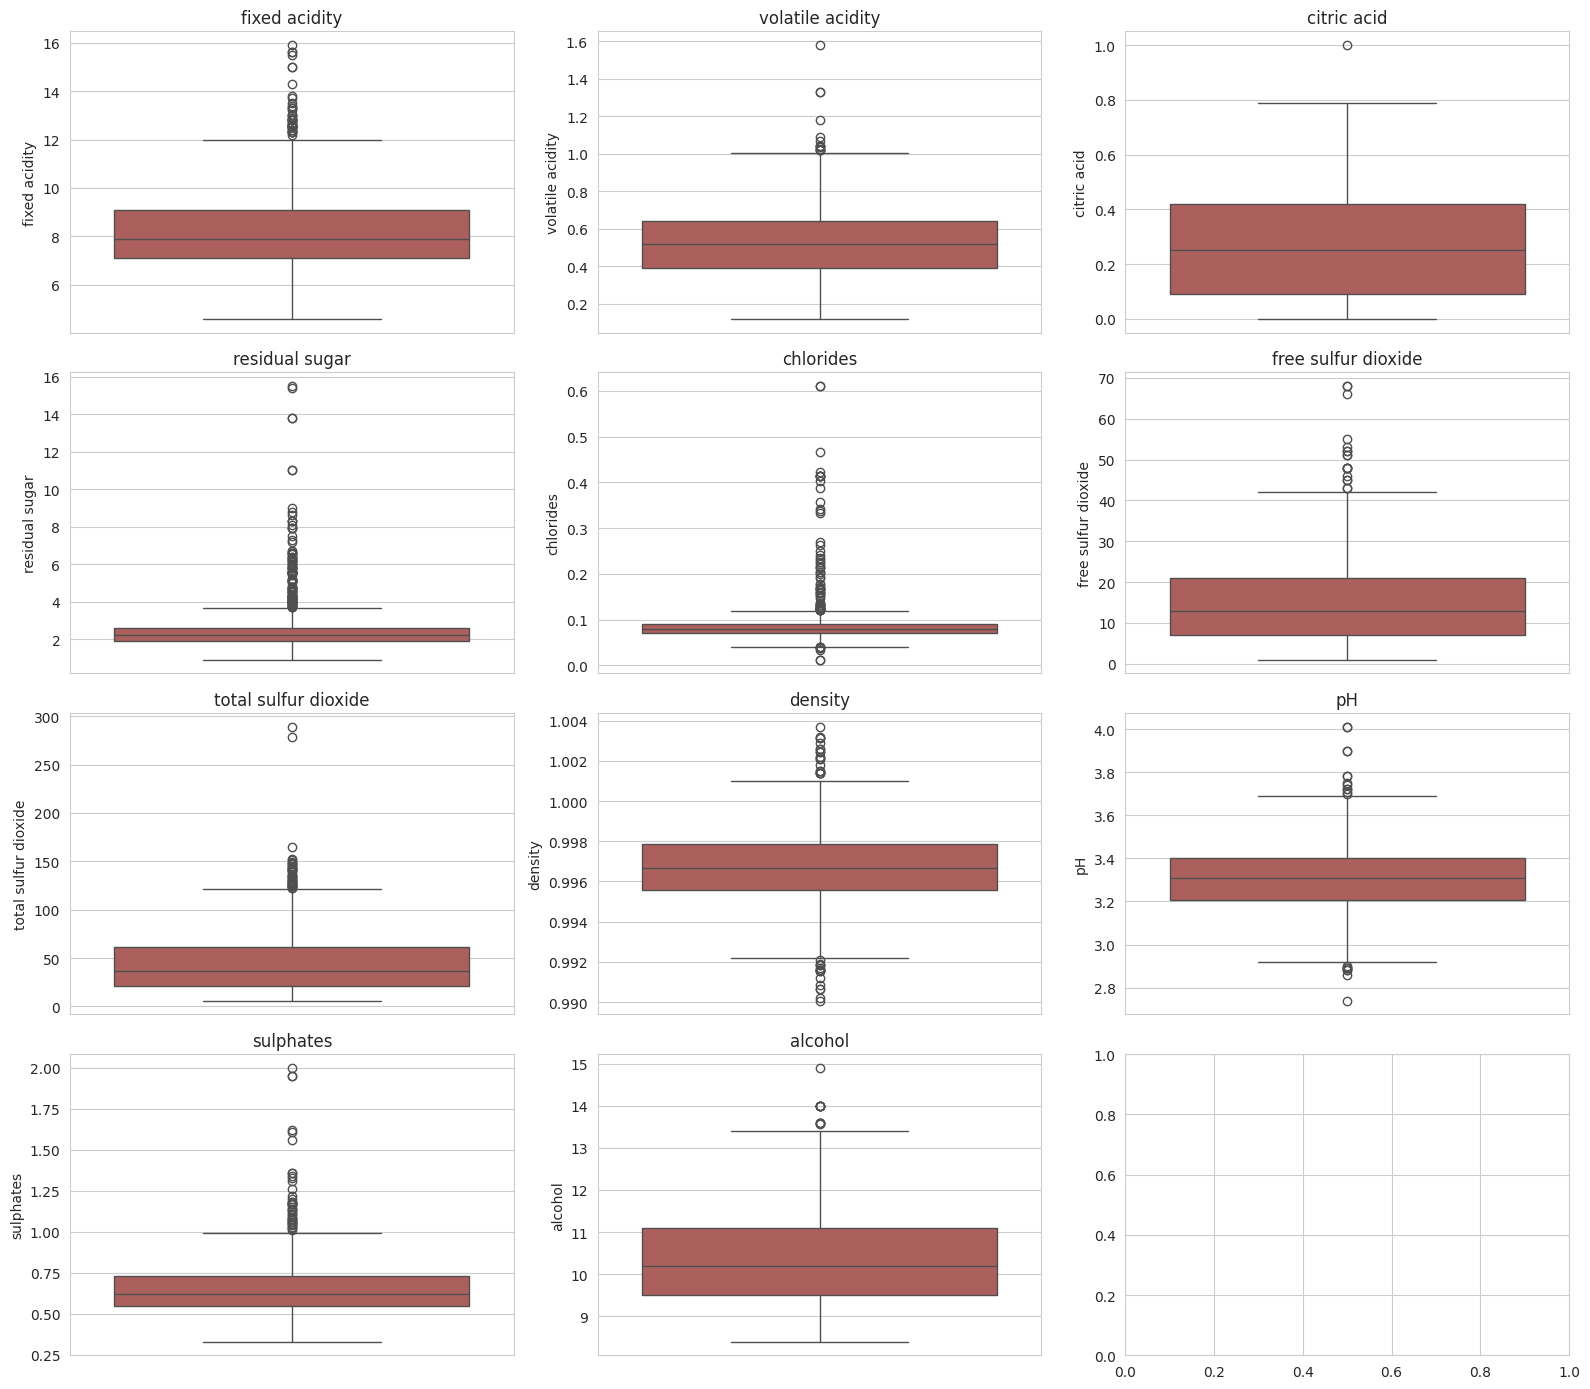

In [ ]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#B85450')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Quantificar outliers via IQR
def contar_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < lim_inf) | (series > lim_sup)).sum()

for col in cols:
    n_out = contar_outliers_iqr(df[col])
    print(f'{col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

fixed acidity: 44 outliers (3.8%)
volatile acidity: 14 outliers (1.2%)
citric acid: 1 outliers (0.1%)
residual sugar: 110 outliers (9.6%)
chlorides: 77 outliers (6.7%)
free sulfur dioxide: 18 outliers (1.6%)
total sulfur dioxide: 40 outliers (3.5%)
density: 36 outliers (3.1%)
pH: 20 outliers (1.7%)
sulphates: 43 outliers (3.8%)
alcohol: 12 outliers (1.0%)


/tmp/ipykernel_886/3473954562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_label', data=df, palette=['#4C72B0', '#722F37'])


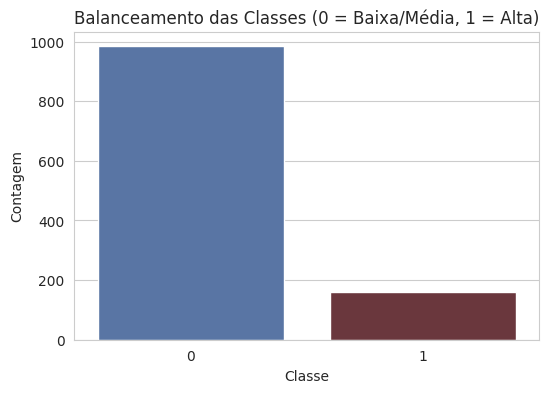

quality_label
0    86.089239
1    13.910761
Name: proportion, dtype: float64


In [ ]:
# Barplot de classificação
plt.figure(figsize=(6,4))
sns.countplot(x='quality_label', data=df, palette=['#4C72B0', '#722F37'])
plt.title('Balanceamento das Classes (0 = Baixa/Média, 1 = Alta)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

print(df['quality_label'].value_counts(normalize=True) * 100)

# 3. Pré-processamento de Dados

In [ ]:
# Confirmar ausência de nulos
print(df.isnull().sum().sum())

0


In [ ]:
# Capping - achatar os valores extremos
def aplicar_capping(df, colunas, fator=1.5):
    df_capped = df.copy()
    for col in colunas:
        Q1, Q3 = df_capped[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lim_inf, lim_sup = Q1 - fator*IQR, Q3 + fator*IQR
        df_capped[col] = df_capped[col].clip(lower=lim_inf, upper=lim_sup)
    return df_capped

colunas_numericas = df.columns.drop(['quality', 'quality_label'])
df_proc = aplicar_capping(df, colunas_numericas)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=['quality', 'quality_label'])
y = df_proc['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Confere o tamanho
print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')
print(f'Proporção classes treino:\n{y_train.value_counts(normalize=True)}')
print(f'Proporção classes teste:\n{y_test.value_counts(normalize=True)}')

Treino: (914, 11), Teste: (229, 11)
Proporção classes treino:
quality_label
0    0.86105
1    0.13895
Name: proportion, dtype: float64
Proporção classes teste:
quality_label
0    0.860262
1    0.139738
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
def criar_features(df):
    df = df.copy()
    # Proporção de SO2 livre em relação ao total — indica eficácia do SO2 como conservante
    df['sulfur_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)

    # Razão álcool/densidade — combina as duas variáveis mais correlacionadas
    df['alcohol_density_ratio'] = df['alcohol'] / df['density']

    # Acidez total percebida (fixa + volátil)
    df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']

    return df

X_train_fe = criar_features(X_train)
X_test_fe = criar_features(X_test)

# 4. Desenvolvimento de Modelos

In [ ]:
from sklearn.linear_model import LogisticRegression

# Cria o modelo de Regressão Logística com alguns parâmetros
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Cria o Random Forest com parâmentros
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=10
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Cria o Boosting com parâmetros
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.model_selection import cross_val_score

# Apresenta os resultados
for nome, modelo, dados in [
    ('Regressão Logística', log_reg, X_train_scaled),
    ('Random Forest', rf, X_train),
    ('Gradient Boosting', gb, X_train)
]:
    scores = cross_val_score(modelo, dados, y_train, cv=5, scoring='f1')
    print(f'{nome} — F1 médio (CV): {scores.mean():.3f} (+/- {scores.std():.3f})')

Regressão Logística — F1 médio (CV): 0.543 (+/- 0.028)
Random Forest — F1 médio (CV): 0.571 (+/- 0.038)
Gradient Boosting — F1 médio (CV): 0.524 (+/- 0.067)


# 5. Avaliação dos Modelos



In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

def avaliar_modelo(nome, y_true, y_pred, y_proba):
    print(f'\n{"="*50}')
    print(f'{nome}')
    print(f'{"="*50}')
    print(f'Acurácia:  {accuracy_score(y_true, y_pred):.3f}')
    print(f'Precisão:  {precision_score(y_true, y_pred):.3f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.3f}')
    print(f'F1-Score:  {f1_score(y_true, y_pred):.3f}')
    print(f'AUC-ROC:   {roc_auc_score(y_true, y_proba):.3f}')
    print('\nRelatório completo:')
    print(classification_report(y_true, y_pred, target_names=['Baixa/Média', 'Alta']))

avaliar_modelo('Regressão Logística', y_test, y_pred_log, y_proba_log)
avaliar_modelo('Random Forest', y_test, y_pred_rf, y_proba_rf)
avaliar_modelo('Gradient Boosting', y_test, y_pred_gb, y_proba_gb)


Regressão Logística
Acurácia:  0.777
Precisão:  0.349
Recall:    0.688
F1-Score:  0.463
AUC-ROC:   0.841

Relatório completo:
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.79      0.86       197
        Alta       0.35      0.69      0.46        32

    accuracy                           0.78       229
   macro avg       0.64      0.74      0.66       229
weighted avg       0.86      0.78      0.80       229


Random Forest
Acurácia:  0.908
Precisão:  0.720
Recall:    0.562
F1-Score:  0.632
AUC-ROC:   0.906

Relatório completo:
              precision    recall  f1-score   support

 Baixa/Média       0.93      0.96      0.95       197
        Alta       0.72      0.56      0.63        32

    accuracy                           0.91       229
   macro avg       0.83      0.76      0.79       229
weighted avg       0.90      0.91      0.90       229


Gradient Boosting
Acurácia:  0.878
Precisão:  0.553
Recall:    0.656
F1-Score:  0.600
AUC-ROC:   

In [ ]:
# Conclusão Final
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'Gradient Boosting'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precisão': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ]
}).round(3)

print(resultados.sort_values('F1-Score', ascending=False))

                Modelo  Acurácia  Precisão  Recall  F1-Score  AUC-ROC
1        Random Forest     0.908     0.720   0.562     0.632    0.906
2    Gradient Boosting     0.878     0.553   0.656     0.600    0.877
0  Regressão Logística     0.777     0.349   0.688     0.463    0.841


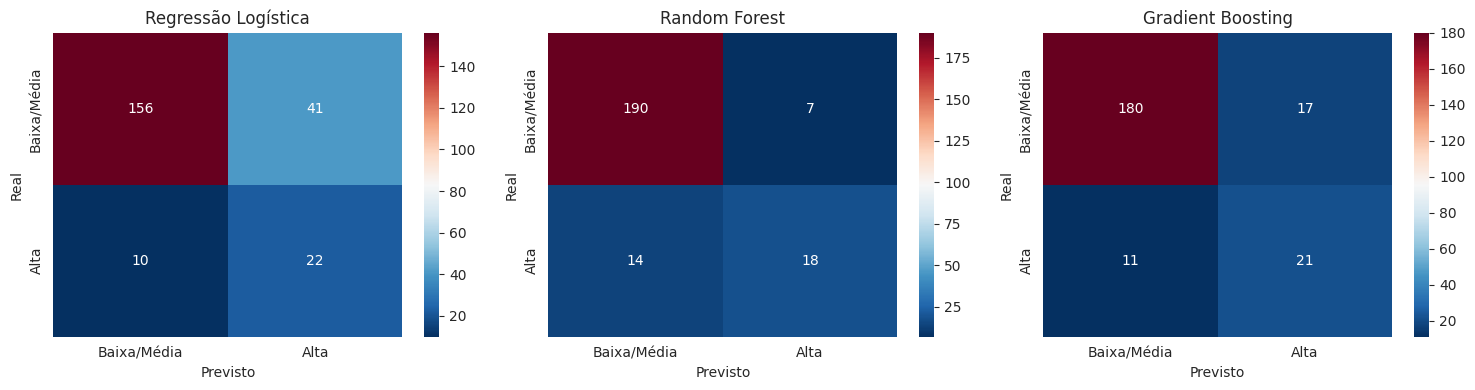

In [ ]:
# HeatMap dos modelos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modelos_preds = [
    ('Regressão Logística', y_pred_log),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for ax, (nome, y_pred) in zip(axes, modelos_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r', ax=ax,
                xticklabels=['Baixa/Média', 'Alta'],
                yticklabels=['Baixa/Média', 'Alta'])
    ax.set_title(nome)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

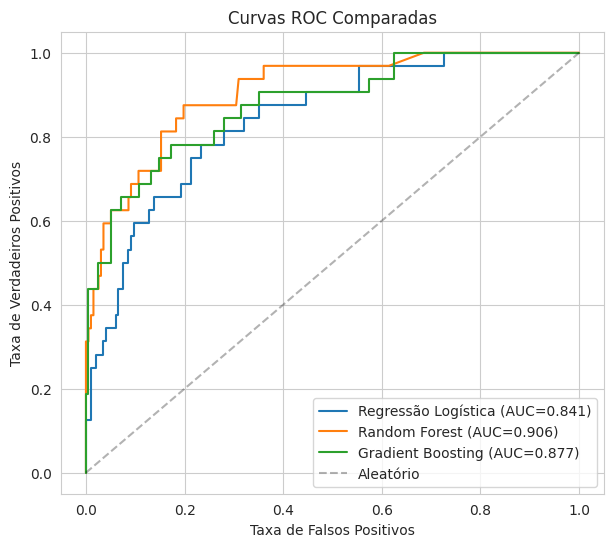

In [ ]:
# Curva Roc dos modelos
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for nome, y_proba in [
    ('Regressão Logística', y_proba_log),
    ('Random Forest', y_proba_rf),
    ('Gradient Boosting', y_proba_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC Comparadas')
plt.legend()
plt.show()

# 6. Interpretação dos Resultados



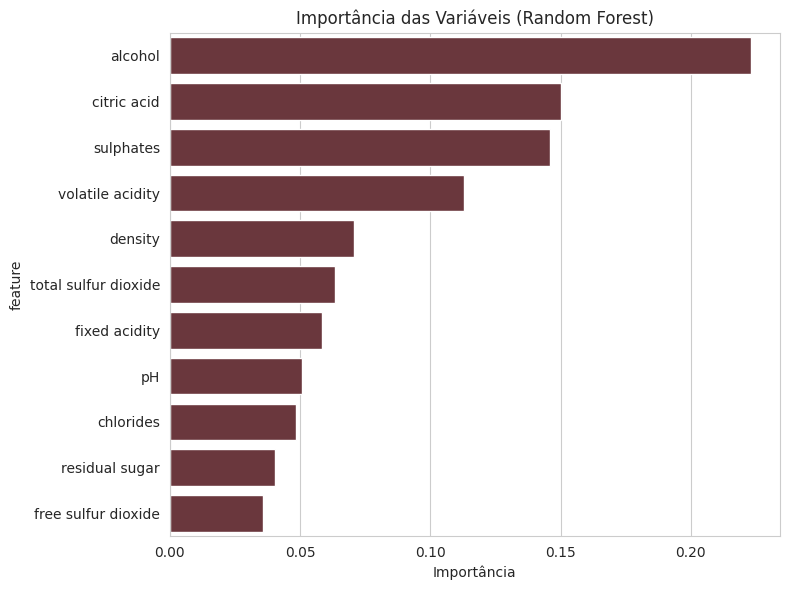

                 feature  importancia
10               alcohol     0.223023
2            citric acid     0.150161
9              sulphates     0.145890
1       volatile acidity     0.112862
7                density     0.070675
6   total sulfur dioxide     0.063575
0          fixed acidity     0.058371
8                     pH     0.050758
4              chlorides     0.048639
3         residual sugar     0.040364
5    free sulfur dioxide     0.035683


In [ ]:
# Relevância das variáveis
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importancias, y='feature', x='importancia', color='#722F37')
plt.title('Importância das Variáveis (Random Forest)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print(importancias)